In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import ( AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier )
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay )
from xgboost import XGBClassifier

In [2]:
"""2. Load the Dataset
The SMS Spam Collection Dataset is used for this mini project. The dataset contains SMS messages classified into two categories:
ham – legitimate message
spam – unwanted/spam message"""
import pandas as pd

df = pd.read_csv(r"D:\Reports\AML-mini-project\SMSSpamCollection.csv",
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="latin-1"
)
df.to_csv(r"D:\Reports\AML-mini-project\SMSSpamCollection_1.csv", index=False)
print("CSV file created successfully!")
print(df.head())

CSV file created successfully!
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
"""3. Dataset Statistics
The shape of the dataset and distribution of the target classes are displayed using the following code."""

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df["label"].value_counts())


Dataset Shape: (5572, 2)

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
"""4. Check for Missing Values
Before preprocessing, missing values are checked.
"""
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
label      0
message    0
dtype: int64


In [5]:
"""5. Convert Class Labels into Numerical Values
Machine learning algorithms require numerical target values. Therefore:
ham → 0
spam → 1"""
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


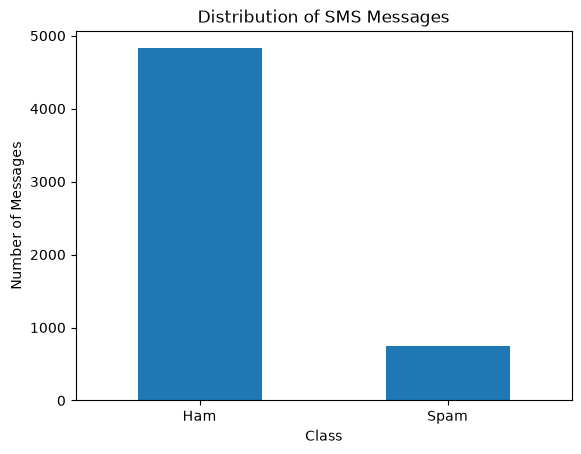

'The graph shows that the number of legitimate messages is significantly higher than the number of spam messages.'

In [6]:
"""6. Exploratory Data Analysis
The distribution of spam and ham messages is visualized using a bar chart.
"""
df["label"].value_counts().plot(
    kind="bar",
    title="Distribution of SMS Messages"
)

plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.xticks(
    ticks=[0, 1],
    labels=["Ham", "Spam"],
    rotation=0
)

plt.show()

"""The graph shows that the number of legitimate messages is significantly higher than the number of spam messages."""

In [7]:
"""7. Separate Input and Target Variables
The message column is used as the input feature, while the label column is used as the target.
"""
X = df["message"]
y = df["label"]

print("Input Shape:", X.shape)
print("Target Shape:", y.shape)

Input Shape: (5572,)
Target Shape: (5572,)


In [8]:
"""8. Split the Dataset into Training and Testing Sets
The dataset is divided into training and testing sets.
80% → Training data
20% → Testing data
Stratification is used to maintain the same class distribution in both sets."""

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 4457
Testing Samples: 1115


In [9]:
"""9. Convert Text into TF-IDF Features
Machine learning algorithms cannot directly process raw text. Therefore, the SMS messages are converted into numerical vectors using TF-IDF (Term Frequency–Inverse Document Frequency)."""

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (4457, 7413)
Testing TF-IDF Shape: (1115, 7413)


In [10]:
"""10. Define the Machine Learning Algorithms
Five different machine learning algorithms are used:
AdaBoost
Gradient Boosting
XGBoost
Extra Trees Classifier
Ridge Classifier"""
models = {

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Ridge Classifier": RidgeClassifier()
}

In [11]:
"""11. Train the Machine Learning Models
Each algorithm is trained using the TF-IDF representation of the SMS messages."""
for name, model in models.items():
    print("Training:", name)
    model.fit(
        X_train_tfidf,
        y_train
    )
print("\nAll models trained successfully.")

Training: AdaBoost
Training: Gradient Boosting
Training: XGBoost
Training: Extra Trees
Training: Ridge Classifier

All models trained successfully.


In [12]:
"""12. Evaluate the Models
The trained models are evaluated using:
Accuracy
Precision
Recall
F1-Score"""

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    precision = precision_score(
        y_test,
        y_pred
    )
    recall = recall_score(
        y_test,
        y_pred
    )
    f1 = f1_score(
        y_test,
        y_pred
    )
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])
results_df = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)
print(results_df.round(4))

           Algorithm  Accuracy  Precision  Recall  F1-Score
0           AdaBoost    0.9220     0.9844  0.4228    0.5915
1  Gradient Boosting    0.9623     0.9820  0.7315    0.8385
2            XGBoost    0.9587     0.9640  0.7181    0.8231
3        Extra Trees    0.9794     1.0000  0.8456    0.9164
4   Ridge Classifier    0.9812     0.9923  0.8658    0.9247


In [13]:
"""13. Classification Report
A detailed classification report can be generated for each algorithm.
"""
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Ham", "Spam"]
        )
    )


AdaBoost
              precision    recall  f1-score   support

         Ham       0.92      1.00      0.96       966
        Spam       0.98      0.42      0.59       149

    accuracy                           0.92      1115
   macro avg       0.95      0.71      0.77      1115
weighted avg       0.93      0.92      0.91      1115


Gradient Boosting
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.98      0.73      0.84       149

    accuracy                           0.96      1115
   macro avg       0.97      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115


XGBoost
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.96      0.72      0.82       149

    accuracy                           0.96      1115
   macro avg       0.96      0.86      0.90      1115
weighted avg       0.96      0.96   

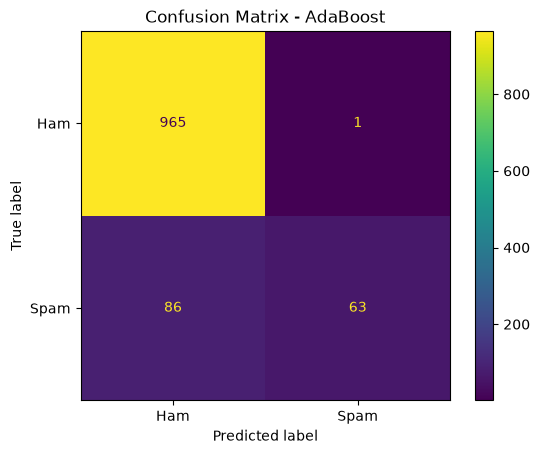

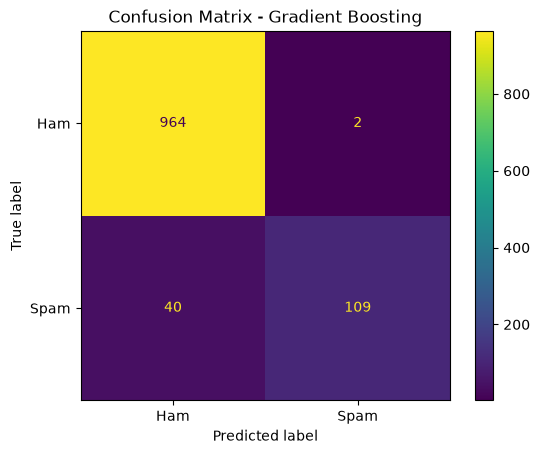

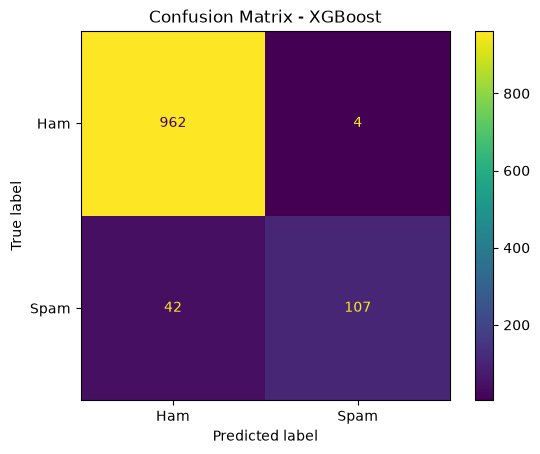

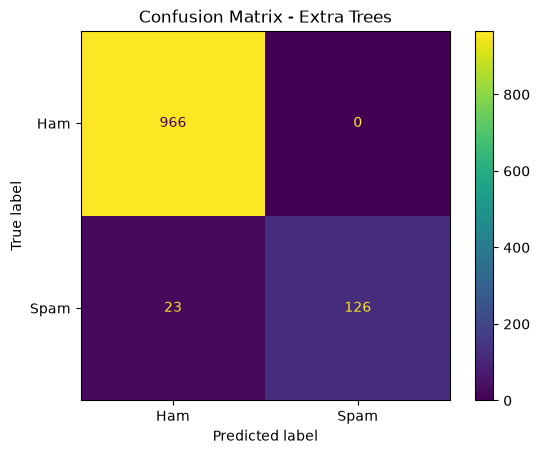

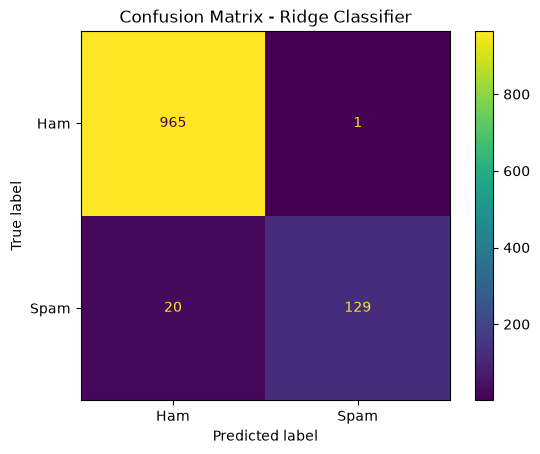

'The confusion matrix contains four important values:\nTrue Negative (TN)\nFalse Positive (FP)\nFalse Negative (FN)\nTrue Positive (TP)\nFor spam detection, reducing false negatives is particularly important because a false negative means a spam message has been incorrectly classified as a legitimate message.'

In [14]:
"""14. Confusion Matrix
A confusion matrix is used to understand the classification performance of each model."""
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(
        y_test,
        y_pred
    )
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Ham", "Spam"]
    )
    disp.plot()
    plt.title(
        f"Confusion Matrix - {name}"
    )
    plt.show()
"""The confusion matrix contains four important values:
True Negative (TN)
False Positive (FP)
False Negative (FN)
True Positive (TP)
For spam detection, reducing false negatives is particularly important because a false negative means a spam message has been incorrectly classified as a legitimate message."""

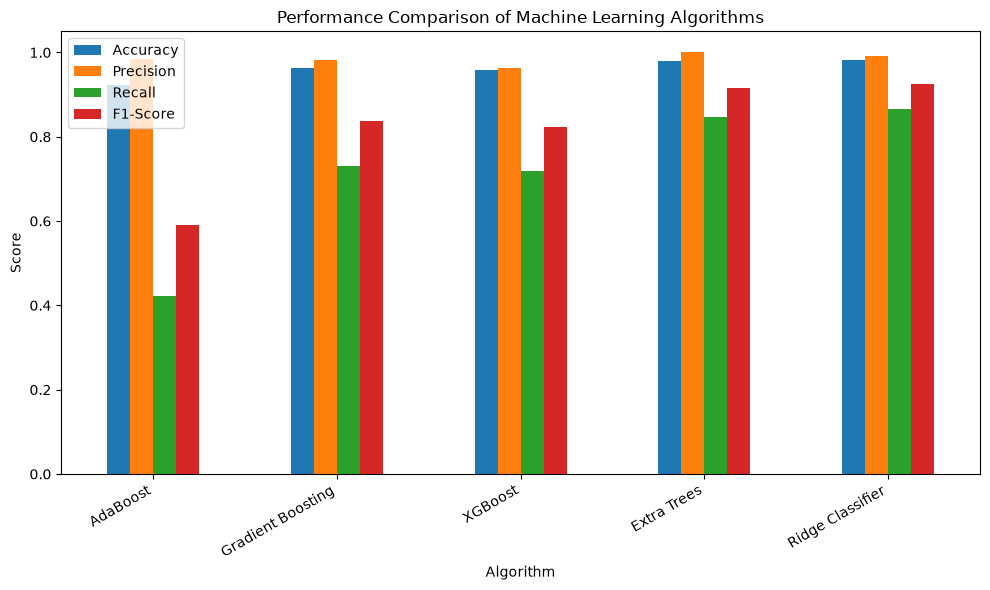

'The graph provides a visual comparison of the four evaluation metrics for all five algorithms.'

In [15]:
"""15. Compare Model Performance
The performance of all five algorithms can be visualized using a bar graph.
"""
results_plot = results_df.set_index(
    "Algorithm"
)
results_plot[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title(
    "Performance Comparison of Machine Learning Algorithms"
)
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(
    rotation=30,
    ha="right"
)
plt.legend()
plt.tight_layout()
plt.show()

"""The graph provides a visual comparison of the four evaluation metrics for all five algorithms."""

In [16]:
"""16. Identify the Best-Performing Algorithm
The algorithm with the highest F1-score is selected as the best-performing model.
"""
best_model = results_df.loc[
    results_df["F1-Score"].idxmax()
]
print("Best Performing Algorithm:")
print(best_model)

Best Performing Algorithm:
Algorithm    Ridge Classifier
Accuracy             0.981166
Precision            0.992308
Recall               0.865772
F1-Score             0.924731
Name: 4, dtype: object
